### Database SQL Visualization


In [ ]:
# Import necessary libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# Suppress warnings to keep output clean
warnings.filterwarnings('ignore')

print("All libraries imported successfully")
print(f"sqlite3 version : {sqlite3.version}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

All libraries imported successfully
sqlite3 version : 2.6.0
Pandas version: 2.2.2
Matplotlib version: 3.10.0


In [ ]:
from google.colab import drive
# Mount Google Drive to access files stored there
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('student_performance.csv')

# Print information about the loaded dataset
print(f"Dataset loaded: {df.shape[0]} students, {df.shape[1]} columns")
print(f"Columns: {df.columns.to_list()}")
print("First 5 rows:")

df.head(5)

Dataset loaded: 30 students, 13 columns
Columns: ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']
First 5 rows:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [ ]:
# Establish a connection to an SQLite database named 'college.db'
# If the file does not exist, SQLite will automatically create it.
# If it exists, it will open the existing database.
conn = sqlite3.connect('college.db')

# Create a cursor object to execute SQL commands
cursor = conn.cursor()

# Export the pandas DataFrame 'df' into an SQLite table named 'students'
# index=False prevents writing the DataFrame index as a column.
# if_exists='replace' will drop the table if it already exists and create a new one.
df.to_sql(
    'students', # The name of the SQL table
    conn,       # The database connection object
    index = False, # Do not write the DataFrame's row index as a column
    if_exists = 'replace' # If table 'students' exists, replace it
)

# Execute an SQL query to count the total number of rows in the 'students' table
cursor.execute("SELECT COUNT(*) FROM STUDENTS")

# Fetch the result of the query. fetchone() retrieves the first row,
# and [0] accesses the first (and only) column of that row.
count = cursor.fetchone()[0]

# Print confirmation messages
print(f"Database 'college.db' created successfully")
print(f"Table 'students' has {count} rows")

Database 'college.db' created successfully
Table 'students' has 30 rows


In [ ]:
# Execute an SQL PRAGMA command to get information about the 'students' table structure
# PRAGMA table_info(table_name) returns metadata about the table's columns.
cursor.execute("PRAGMA table_info(students)")
columns_info = cursor.fetchall()

print("Table structure of 'students':")
print(f"{'Columns Name':<25} {'Data Types':<12}")

print("-" * 38)

# Iterate through the fetched column information and print column names and data types
# col[1] typically holds the column name and col[2] holds the data type in PRAGMA table_info output.
for col in columns_info:
    print(f"{col[1]:<25} {col[2]:<12}")

Table structure of 'students':
Columns Name              Data Types  
--------------------------------------
student_id                INTEGER     
name                      TEXT        
age                       INTEGER     
gender                    TEXT        
department                TEXT        
semester                  INTEGER     
math_score                INTEGER     
science_score             INTEGER     
english_score             INTEGER     
programming_score         INTEGER     
attendance_percentage     INTEGER     
city                      TEXT        
admission_year            INTEGER     


The Standard SQL Query Pattern

```sql
SELECT column1, column2
FROM table_name
WHERE condition
GROUP BY column1
HAVING group_condition
ORDER BY column DESC
LIMIT 10;
```

In [ ]:
def run_query(sql, description=""):
  """
  Runs a SQL query and returns results as a Pandas DataFrame.

  Parameters:
  -----------
  sql         : str - The SQL query to be executed.
  description : str - Optional description for the query.

  Returns:
  -----------
  Pandas DataFrame containing the query results
  """
  if description:
    print(f"\n{'='*55}")
    print(f"{description}")
    print(f"{'='*55}")

  result = pd.read_sql_query(sql, conn)

  # The function now returns the DataFrame for rich display in Colab
  return result

SQL Query 1 - Basic SELECT

In [ ]:
query1 = """
  SELECT student_id, name, department, math_score, attendance_percentage
  FROM students
  LIMIT 10
"""

result1 = run_query(query1, "Basic SELECT")
display(result1)


Basic SELECT


,student_id,name,department,math_score,attendance_percentage
0,1001,Aarav Sharma,Computer Science,85,92
1,1002,Priya Patel,Computer Science,76,87
2,1003,Rohit Verma,Electronics,65,78
3,1004,Sneha Reddy,Mechanical,70,95
4,1005,Arjun Nair,Computer Science,92,90
5,1006,Meera Joshi,Electronics,58,72
6,1007,Kiran Kumar,Civil,73,85
7,1008,Divya Singh,Computer Science,88,96
8,1009,Rahul Mishra,Mechanical,62,68
9,1010,Ananya Das,Computer Science,95,98


SQL Query 2 - ORDER BY + LIMIT

In [ ]:
query2 = """
  SELECT student_id, name, department, math_score
  FROM students
  ORDER BY math_score DESC
  LIMIT 10
"""

result2 = run_query(query2, "ORDER BY + LIMIT")
display(result2)


ORDER BY + LIMIT


,student_id,name,department,math_score
0,1010,Ananya Das,Computer Science,95
1,1022,Tanvi Mehta,Computer Science,93
2,1005,Arjun Nair,Computer Science,92
3,1030,Akanksha Yadav,Computer Science,91
4,1018,Swati Kulkarni,Computer Science,90
5,1008,Divya Singh,Computer Science,88
6,1016,Ritu Agarwal,Electronics,87
7,1025,Amit Bose,Computer Science,86
8,1001,Aarav Sharma,Computer Science,85
9,1027,Gaurav Shukla,Computer Science,84


SQL Query 3 - WHERE filter

In [ ]:
query3 = """
  SELECT student_id, name, department, math_score
  FROM students
  WHERE math_score > 80
  ORDER BY math_score DESC
  LIMIT 10
"""

result3 = run_query(query3, "WHERE filter")
display(result3)


WHERE filter


,student_id,name,department,math_score
0,1010,Ananya Das,Computer Science,95
1,1022,Tanvi Mehta,Computer Science,93
2,1005,Arjun Nair,Computer Science,92
3,1030,Akanksha Yadav,Computer Science,91
4,1018,Swati Kulkarni,Computer Science,90
5,1008,Divya Singh,Computer Science,88
6,1016,Ritu Agarwal,Electronics,87
7,1025,Amit Bose,Computer Science,86
8,1001,Aarav Sharma,Computer Science,85
9,1027,Gaurav Shukla,Computer Science,84


SQL Query 4 - Multiple WHERE conditions

In [ ]:
query4 = """
  SELECT student_id, name, department, math_score
  FROM students
  WHERE math_score > 80 AND department = 'Computer Science'
  ORDER BY math_score DESC
  LIMIT 10
"""

result4 = run_query(query4, "Multiple WHERE conditions")
display(result4)


Multiple WHERE conditions


,student_id,name,department,math_score
0,1010,Ananya Das,Computer Science,95
1,1022,Tanvi Mehta,Computer Science,93
2,1005,Arjun Nair,Computer Science,92
3,1030,Akanksha Yadav,Computer Science,91
4,1018,Swati Kulkarni,Computer Science,90
5,1008,Divya Singh,Computer Science,88
6,1025,Amit Bose,Computer Science,86
7,1001,Aarav Sharma,Computer Science,85
8,1027,Gaurav Shukla,Computer Science,84
9,1013,Suresh Rao,Computer Science,83


SQL Query 5 - GROUP BY with Aggregate Function

In [ ]:
query5 = """
  SELECT
    department,
    COUNT(*) AS num_students,
    ROUND(AVG(math_score), 2) AS avg_math_score,
    ROUND(AVG(science_score), 2) AS avg_science_score,
    ROUND(AVG(english_score), 2) AS avg_english_score,
    ROUND(AVG(programming_score), 2) AS avg_programming_score,
    ROUND(AVG(attendance_percentage), 2) AS avg_attendance_percentage
  FROM students
  GROUP BY department
  ORDER BY department
"""

result5 = run_query(query5, "GROUP BY with Aggregate Function")
display(result5)


GROUP BY with Aggregate Function


,department,num_students,avg_math_score,avg_science_score,avg_english_score,avg_programming_score,avg_attendance_percentage
0,Civil,5,63.40,66.60,65.20,40.60,74.60
1,Computer Science,13,85.62,84.46,80.85,89.23,90.69
2,Electronics,6,71.00,74.17,70.83,61.50,80.33
3,Mechanical,6,71.00,76.50,70.50,49.33,83.50


SQL Query 6 - HAVING (filter on groups)

In [ ]:
query6 = """
  SELECT
    department,
    ROUND(AVG(math_score), 2) AS avg_math,
    COUNT(*) AS num_students
  FROM students
  GROUP BY department
  HAVING AVG(math_score) > 70
  ORDER BY avg_math DESC
"""

result6 = run_query(query6, "HAVING (filter on groups)")
display(result6)


HAVING (filter on groups)


,department,avg_math,num_students
0,Computer Science,85.62,13
1,Mechanical,71.00,6
2,Electronics,71.00,6


SQL Query 7 - Gender-wise analysis

In [ ]:
query7 = """
  SELECT
    gender,
    ROUND(AVG(math_score), 2) AS avg_math,
    ROUND(AVG(science_score), 2) AS avg_science,
    ROUND(AVG(english_score), 2) AS avg_english,
    ROUND(AVG(programming_score), 2) AS avg_programming,
    ROUND(AVG(attendance_percentage), 2) AS avg_attendance
  FROM students
  GROUP BY gender
"""

result7 = run_query(query7, "Gender-wise analysis")

display(result7)



Gender-wise analysis


,gender,avg_math,avg_science,avg_english,avg_programming,avg_attendance
0,Female,78.47,81.20,80.80,70.2,88.53
1,Male,73.67,74.47,67.53,65.0,80.47


SQL Query 8 - Top 10 Students by Total Score

In [ ]:
query8 = """
  SELECT
    student_id,
    name,
    department,
    math_score + science_score + english_score + programming_score AS total_score
  FROM students
  ORDER BY total_score DESC
  LIMIT 10
"""
result8 = run_query(query8, "Top 10 Students by Total Score")
display(result8)


Top 10 Students by Total Score


,student_id,name,department,total_score
0,1010,Ananya Das,Computer Science,371
1,1022,Tanvi Mehta,Computer Science,367
2,1030,Akanksha Yadav,Computer Science,365
3,1005,Arjun Nair,Computer Science,356
4,1008,Divya Singh,Computer Science,356
5,1018,Swati Kulkarni,Computer Science,354
6,1025,Amit Bose,Computer Science,336
7,1013,Suresh Rao,Computer Science,334
8,1020,Nisha Kapoor,Computer Science,327
9,1001,Aarav Sharma,Computer Science,326


SQL Query 9 - Create a department table fot JOIN demonstration

In [ ]:
dept_data = {
    'dept_code': ['CS', 'ECE', 'ME', 'EE', 'IT'],
    'dept_name': ['Computer Science', 'Electronics', 'Mechanical', 'Electrical', 'Information Technology'],
    'hod_name': ['Dr. Dahal', 'Dr. Sharma', 'Dr. Patel', 'Dr. Verma', 'Dr. Gupta'],
    'estblished_year': [1990, 1988, 2000, 1995, 2005],
    'intake': [60, 60, 60, 60, 60] # Added an extra value to match other list lengths
}

dept_df = pd.DataFrame(dept_data)
dept_df.to_sql('departments', conn, index=False, if_exists='replace')

print("Created 'department' table:")
print(dept_df.to_string(index=False))

dept_map = {
    'Computer Science': 'CS',
    'Electronics': 'ECE',
    'Mechanical': 'ME',
    'Electrical': 'EE',
    'Information Technology': 'IT'
}

df['dept_code'] = df['department'].map(dept_map)

df.to_sql('students', conn, index=False, if_exists='replace')

print("\nUpdated 'students' table with 'dept_code' column:")
print(df.to_string(index=False))

Created 'department' table:
dept_code              dept_name   hod_name  estblished_year  intake
       CS       Computer Science  Dr. Dahal             1990      60
      ECE            Electronics Dr. Sharma             1988      60
       ME             Mechanical  Dr. Patel             2000      60
       EE             Electrical  Dr. Verma             1995      60
       IT Information Technology  Dr. Gupta             2005      60

Updated 'students' table with 'dept_code' column:
 student_id           name  age gender       department  semester  math_score  science_score  english_score  programming_score  attendance_percentage               city  admission_year dept_code
       1001   Aarav Sharma   19   Male Computer Science         2          85             78             72                 91                     92             Mumbai            2023        CS
       1002    Priya Patel   20 Female Computer Science         2          76             82             88          

INNER JOIN : Combine Students with department

In [ ]:
query_join = """
  SELECT
    s.name,
    s.math_score,
    d.dept_name,
    d.hod_name,
    d.estblished_year
  FROM students AS s
  INNER JOIN departments AS d
  ON s.dept_code = d.dept_code
  ORDER BY s.math_score DESC
  LIMIT 8
"""

result_join = run_query(query_join, "JOIN: Students with Department Details (INNER JOIN)")
display(result_join)


JOIN: Students with Department Details (INNER JOIN)


,name,math_score,dept_name,hod_name,estblished_year
0,Ananya Das,95,Computer Science,Dr. Dahal,1990
1,Tanvi Mehta,93,Computer Science,Dr. Dahal,1990
2,Arjun Nair,92,Computer Science,Dr. Dahal,1990
3,Akanksha Yadav,91,Computer Science,Dr. Dahal,1990
4,Swati Kulkarni,90,Computer Science,Dr. Dahal,1990
5,Divya Singh,88,Computer Science,Dr. Dahal,1990
6,Ritu Agarwal,87,Electronics,Dr. Sharma,1988
7,Amit Bose,86,Computer Science,Dr. Dahal,1990


UNIT 3: Data Visualization with Matplotlib

Now we turn our SQL results into professional charts.


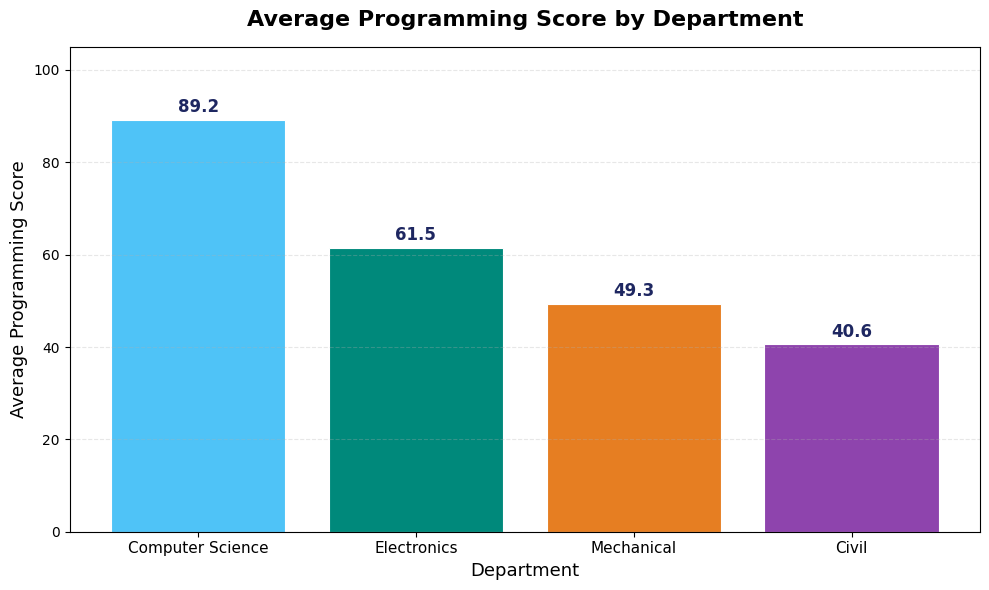

In [ ]:
chart1_sql = """
  SELECT department, ROUND(AVG(programming_score), 2) AS avg_programming
  FROM students
  GROUP BY department
  ORDER BY avg_programming DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
  chart1_data['department' ],
  chart1_data['avg_programming' ], # Changed to avg_programming
  color = bar_colors,
  edgecolor='white',
  linewidth=0.8
)

for bar in bars:
  # Loop through each bar object
  height = bar.get_height()
  # .get_height() returns the bar's height (= the avg_programming value)
  ax.text(
    bar.get_x()+ bar.get_width() / 2, # x position: center of bar
    height + 0.8,
    f'{height:.1f}',
    ha='center', va='bottom',
    fontsize=12, fontweight='bold',
    color='#1E2761'
  )

ax.set_title('Average Programming Score by Department', fontsize=16, fontweight='bold', pad=15) # Updated title
ax.set_xlabel('Department', fontsize=13)
ax.set_ylabel('Average Programming Score', fontsize=13) # Updated label
ax.set_ylim(0, 105) # y-axis from 0 to 105 so labels above bars fit
ax.tick_params(axis='x', labelsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
# axis='y' adds horizontal gridlines only
# alpha=0.3 makes gridlines 70% transparent
# linestyle=' -- ' makes them dashed

plt.tight_layout() # Adjusts spacing to prevent label clipping
# Displays the chart

plt.show()

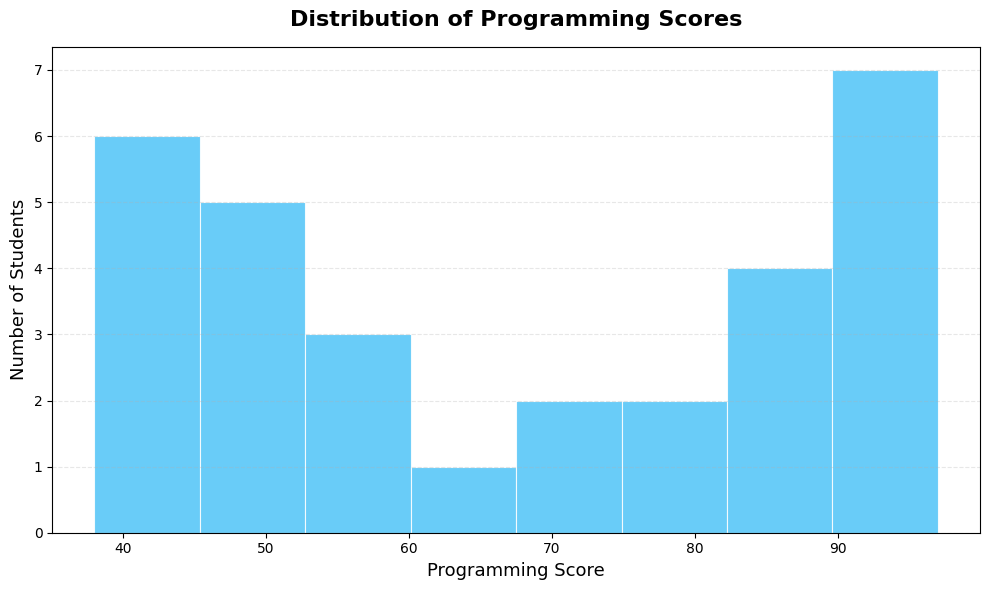

In [ ]:
# Get programming scores as a list
prog_scores = df['programming_score'].tolist()
# .tolist() converts a Pandas Series to a regular Python list
# Matplotlib's hist() works with both - tolist() is just explicit

fig, ax = plt.subplots(figsize=(10,6))

n, bins, patches = ax.hist(
  prog_scores,
  bins=8,
  color='#4FC3F7',
  edgecolor='white',
  linewidth=0.8,
  alpha=0.85
)

ax.set_title('Distribution of Programming Scores', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Programming Score', fontsize=13)
ax.set_ylabel('Number of Students', fontsize=13)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Sample dataset (replace with your own CSV)
df = pd.DataFrame({
'Category': np.random.choice(['A', 'B','C','D'], 100),
'Value': np.random.randint(10, 100, 100),
'Score': np.random.randint(1, 10, 100)
})

df.head()

,Category,Value,Score
0,B,36,5
1,A,24,7
2,B,62,9
3,B,45,5
4,C,45,9


In [ ]:
import plotly.express as px

category_counts = df['Category'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']

fig = px.bar(
  category_counts,
  x='Category',
  y='Count',
  color='Category',
  title='Interactive Category Distribution',
  text='Count'
)

fig.update_traces(textposition='outside')
fig.update_layout(xaxis_title="Category", yaxis_title="Count")

fig.show()

Practice Questions


1: Write a SQL query to find the average programming score for female students only.

2: What is the difference between WHERE and HAVING? Write one example of each using the students table.

3: Write a SQL query to find all departments where the average attentknce is above 85%.

4: What does pd.read_sq1_query() return? What two arguments does it require?

5: Modify Chart 1 (bar chart) to show average PROGRAMMING scores instead of math scores.

### Question 1: SQL query for average programming score for female students

In [ ]:
query_q1 = """
  SELECT
    gender,
    ROUND(AVG(programming_score), 2) AS avg_programming_score
  FROM students
  WHERE gender = 'Female'
  GROUP BY gender
"""

result_q1 = run_query(query_q1, "Average programming score for female students")
display(result_q1)


Average programming score for female students


,gender,avg_programming_score
0,Female,70.2


### Question 2: Difference between WHERE and HAVING

The `WHERE` and `HAVING` clauses both filter data based on specified conditions, but they operate at different stages of the SQL query processing:

*   **`WHERE` Clause**: Filters individual rows *before* they are grouped. It cannot contain aggregate functions (like `AVG()`, `SUM()`, `COUNT()`, etc.).
    *   **Example**: Filtering students based on their individual math scores.

*   **`HAVING` Clause**: Filters groups of rows *after* they have been grouped and aggregate functions have been applied. It can contain aggregate functions.
    *   **Example**: Filtering departments based on the average math score of students within each department.

Let's see examples for each using the `students` table:

#### Example using `WHERE` clause:

In [ ]:
query_where_example = """
  SELECT
    name, department, math_score
  FROM students
  WHERE math_score > 90
"""

result_where = run_query(query_where_example, "Example of WHERE clause (students with math score > 90)")
display(result_where)


Example of WHERE clause (students with math score > 90)


,name,department,math_score
0,Arjun Nair,Computer Science,92
1,Ananya Das,Computer Science,95
2,Tanvi Mehta,Computer Science,93
3,Akanksha Yadav,Computer Science,91


#### Example using `HAVING` clause:

In [ ]:
query_having_example = """
  SELECT
    department,
    ROUND(AVG(attendance_percentage), 2) AS avg_attendance
  FROM students
  GROUP BY department
  HAVING AVG(attendance_percentage) > 85
"""

result_having = run_query(query_having_example, "Example of HAVING clause (departments with average attendance > 85%)")
display(result_having)


Example of HAVING clause (departments with average attendance > 85%)


,department,avg_attendance
0,Computer Science,90.69


### Question 3: SQL query for departments with average attendance above 85%

In [ ]:
query_q3 = """
  SELECT
    department,
    ROUND(AVG(attendance_percentage), 2) AS avg_attendance
  FROM students
  GROUP BY department
  HAVING AVG(attendance_percentage) > 85
  ORDER BY avg_attendance DESC
"""

result_q3 = run_query(query_q3, "Departments with average attendance above 85%")
display(result_q3)


Departments with average attendance above 85%


,department,avg_attendance
0,Computer Science,90.69


## Resources